In [1]:
from notebook.services.config import ConfigManager
cm = ConfigManager()
cm.update('livereveal', {
        'width': 1920,
        'height': 1080,
        'scroll': True,
})

{'width': 1920, 'height': 1080, 'scroll': True}

# Week 08: Wednesday, AST 5011: Astrophysical Systems

## General Relativity and Cosmology 

### Michael Coughlin <cough052@umn.edu>

With contributions from Frank van den Bosch (Yale).

Textbook reference: *Introduction to Galaxy Formation and Evolution* by Cimatti, Fraternali, and Nipoti (CFN), Ch. 2.

## What Is Cosmology?

Cosmology is the study of the structure and evolution of the Universe
as a whole.

Modern cosmology is founded on Einstein’s General Relativity (GR),
according to which the geometry of space–time is determined by the
matter and energy it contains. This is fundamentally different from
classical physics, where space and time are treated as absolute and
independent of matter.

In General Relativity, matter and energy determine the curvature of
space–time, and that curvature in turn determines the motion of matter
and radiation.

Despite being based on GR, cosmology without perturbations is one of
the simplest applications of the theory. This is because we assume
very strong symmetries on large scales.

Observations indicate that, when averaged over sufficiently large
volumes, the Universe is both homogeneous and isotropic. These
assumptions greatly restrict the possible forms of the space–time
metric and make the problem tractable without requiring the full
technical machinery of GR.


## The Metric Tensor

The central object in General Relativity is the **metric tensor** $g_{\mu\nu}$. It tells you how to measure distances in curved space-time.

The invariant interval between two nearby events is:

$$
ds^2 = g_{\mu\nu} \, dx^\mu \, dx^\nu
$$

For purely spatial distances at fixed time:

$$
dl^2 = g_{ij} \, dx^i \, dx^j
$$

Key properties:
- The metric encodes all geometric information: curvature, angles, volumes, causal structure.
- Its numerical components depend on the coordinate system, but the interval $ds^2$ is invariant.
- In flat space with Cartesian coordinates, $g_{ij} = \delta_{ij}$. In polar coordinates, $dl^2 = dr^2 + r^2 d\theta^2$ — different metric, same space.
- In special relativity (Minkowski space), $ds^2 = c^2 dt^2 - dx^2 - dy^2 - dz^2$.

### 2D Surfaces of Constant Curvature

To build intuition before tackling 4D space-time, consider 2D surfaces.

**2D Sphere** embedded in 3D with radius $a$. Using intrinsic coordinates $(\theta, \phi)$:

$$
dl^2 = a^2 (d\theta^2 + \sin^2\theta \, d\phi^2)
$$

Defining a unitless radial parameter $r = \sin\theta$:

$$
dl^2 = a^2 \left( \frac{dr^2}{1 - r^2} + r^2 \, d\phi^2 \right)
$$

The parameter $a$ acts as a **scale factor** — it sets the overall size of the sphere.

**2D Saddle** (negative curvature): same form but with $1 + r^2$ in the denominator.

### 2D Surfaces

We can summarize the metrics of 2D surfaces using a curvature parameter $K$, where 

$$
K = 
\begin{cases}
+1 & \text{2D sphere (positive curvature)} \\
0 & \text{2D Euclidean plane (zero curvature)} \\
-1 & \text{2D saddle (negative curvature)}
\end{cases}
$$

In terms of this parameter, the line element for a surface of constant curvature can be written in a unified form:

$$
dl^2 = a^2 \left( \frac{dr^2}{1 - K r^2} + r^2 d\phi^2 \right)
$$

This gives the corresponding metric tensor:

$$
g_{ij} =
\begin{pmatrix}
\dfrac{a^2}{1 - K r^2} & 0 \\
0 & a^2 r^2
\end{pmatrix}
$$

- For $K = +1$, this corresponds to a 2D sphere with **positive curvature**.  
- For $K = 0$, this corresponds to the 2D Euclidean plane with **zero curvature**.  
- For $K = -1$, this corresponds to the 2D saddle surface with **negative curvature**.  

## Exercise 1: Expansion and the Scale Factor

The scale factor $a(t)$ describes how distances in the Universe change with time. The relationship between scale factor and redshift is $a = a_0 / (1+z)$, with $a_0 = 1$ today.

**Task:**
1. A galaxy is observed at redshift $z = 2$. By what factor have all distances in the Universe expanded since the light was emitted?
2. If the galaxy is currently at a comoving distance of 5000 Mpc, what was the proper distance to it when the light was emitted?
3. Compute and plot how the proper distance to this galaxy changes with redshift from $z = 5$ to $z = 0$, using $l(z) = a(z) \times r_{\rm comoving}$.
4. Does the proper distance have a minimum as a function of redshift? Why or why not?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

r_comoving = 5000.0  # Mpc (comoving distance today)

# Part 1: expansion factor since z = 2
z_em = 2.0
expansion_factor = ... # FILL IN
print(f"Distances have expanded by a factor of {expansion_factor:.1f} since z = {z_em}")

# Part 2: proper distance at emission
a_em = ... # FILL IN
l_em = ... # FILL IN
print(f"Proper distance at emission: {l_em:.0f} Mpc")

# Part 3: proper distance vs redshift
z_arr = np.linspace(0, 5, 200)
a_arr = ... # FILL IN
l_arr = ... # FILL IN

plt.figure(figsize=(5, 3.5))
plt.plot(z_arr, l_arr)
plt.xlabel('Redshift z')
plt.ylabel('Proper distance (Mpc)')
plt.title('Proper distance to a galaxy at fixed comoving distance')
plt.show()

# Part 4: does the proper distance have a minimum?
# FILL IN: comment on whether there is a minimum and why

<details>
<summary>Solution</summary>

```python
expansion_factor = (1 + z_em)
a_em = 1.0 / (1 + z_em)
l_em = a_em * r_comoving
a_arr = 1.0 / (1 + z_arr)
l_arr = a_arr * r_comoving
```

The proper distance decreases monotonically toward higher redshift because $a(z)$ decreases as $1/(1+z)$. There is no minimum — the plot simply shows $l \propto 1/(1+z)$. This is because we are holding the comoving coordinate fixed and only varying the scale factor. The proper distance at $z = 2$ was about 1667 Mpc, one-third of today's value, illustrating that the Universe was physically smaller in the past even though the comoving coordinate of the galaxy hasn't changed.

</details>

## Metric of Space-Time and the Cosmological Principle

Now that we have seen how to derive the metric of a general Riemannian space, we turn our attention to the metric of space-time.

Observations show that the Universe is homogeneous and isotropic on large scales:

- **Cosmological Principle**: The Universe looks the same in all directions (isotropy) and at all locations (homogeneity).  
- **Copernican Principle**: Our location in the Universe is not special; there is no preferred point.  
- This is consistent with observations and follows the logic of Occam’s razor: there is no reason for any location to be special.

From isotropy, the only allowed motion is global expansion or contraction.  
From homogeneity, the metric is independent of location, so

$$
g_{\mu\nu}(x) = g_{\mu\nu}
$$

We therefore seek a general 3D Riemannian space that can be embedded in a (3+1)D space-time. The metric of a homogeneous and isotropic 3D Riemannian space is

$$
dl^2 = a^2(t) \left( \frac{dr^2}{1 - K r^2} + r^2 \left( d\theta^2 + \sin^2\theta \, d\phi^2 \right) \right)
$$

where:

- $a(t)$ is the scale factor and carries the dimension of length.  
- All other quantities ($r$, $K$, $\theta$, $\phi$) are unitless.  

This metric provides the spatial geometry of the Universe at a given cosmic time $t$, and forms the basis for the Friedmann–Lemaître–Robertson–Walker (FLRW) metric when combined with the time dimension.


## The Friedmann–Robertson–Walker (FRW) Metric

By embedding the 3D homogeneous and isotropic Riemannian space in a (3+1)D space-time, we obtain the Friedmann–Robertson–Walker (FRW) metric:

$$
ds^2 = c^2 dt^2 - a^2(t) \left( \frac{dr^2}{1 - K r^2} + r^2 \left( d\theta^2 + \sin^2\theta \, d\phi^2 \right) \right)
$$

The parameters in the FRW metric have the following meanings:

- $t$ is the proper time, representing the time measured by a standard clock carried by a fundamental observer.  

- $K$ is the curvature parameter, indicating the global curvature of space. It can take the values $+1$, $0$, or $-1$, corresponding to a closed, flat, or open universe, respectively.  

- $a(t)$ is the scale factor, which converts the comoving coordinates $(r, \theta, \phi)$ into physical distances.  

- $(r, \theta, \phi)$ are comoving coordinates. They label fundamental observers and remain fixed with respect to the expanding or contracting Universe.

A fundamental observer is one who, in an unperturbed FRW universe, observes the universe to be isotropic. The set of all fundamental observers defines a cosmological rest frame at each point in space.


### Proper Distance Between Fundamental Observers

The proper distance is defined as the spatial distance between two fundamental observers at a given **proper time** $t$.  

In an FRW universe, the proper distance $l$ is related to the comoving distance by the scale factor $a(t)$:

$$
l = \int dl = a(t) \int_0^r \frac{dr'}{\sqrt{1 - K {r'}^2}} = a(t) \, \chi(r)
$$

Here we have assumed a coordinate choice such that one observer is at the origin:

$$
(r, \theta, \phi) = (0, 0, 0)
$$

and the other is at

$$
(r, \theta, \phi) = (r, 0, 0)
$$

The function $\chi(r)$ gives the **comoving distance** between the observers and depends on the curvature $K$:

$$
\chi(r) =
\begin{cases}
\sin^{-1} r & \text{if } K = +1 \\
r & \text{if } K = 0 \\
\sinh^{-1} r & \text{if } K = -1
\end{cases}
$$

Thus, the proper distance between two fundamental observers is simply the scale factor multiplied by the comoving distance:

$$
l = a(t) \, \chi(r)
$$


### Conformal Time in the FRW Metric

In addition to proper time $t$, we can define the conformal time $\tau$, which is unitless:

$$
\tau(t) = \int_0^t \frac{c \, dt'}{a(t')}
$$

The advantage of using conformal time is that it corresponds to an actual distance measure in comoving coordinates. In contrast, the comoving radial coordinate $r$ is only a coordinate label and does not directly measure physical distance.

In terms of conformal time $\tau$ and comoving coordinates, the FRW metric can be rewritten as:

$$
ds^2 = a^2(\tau) \left( d\tau^2 - d\chi^2 - f_K^2(\chi) \left( d\theta^2 + \sin^2\theta \, d\phi^2 \right) \right)
$$

Here, $\chi$ is the comoving radial coordinate and the function $f_K(\chi)$ depends on the curvature $K$:

$$
f_K(\chi) =
\begin{cases}
\sin \chi & \text{if } K = +1 \\
\chi & \text{if } K = 0 \\
\sinh \chi & \text{if } K = -1
\end{cases}
$$

- The conformal time $\tau$ represents the total comoving distance that light could have travelled since $t=0$.  
- During a proper time interval $dt$, a photon travels a proper distance $c\, dt$.  
- During a conformal time interval $d\tau$, the photon travels a comoving distance $d\chi = d\tau$.


### Units and Normalization in Cosmology

A word of caution about units:

- In the FRW metric, the coordinates $(r, \theta, \phi)$ are unitless.  
- Proper time $t$ has units of time, but conformal time $\tau$ is unitless.  
- Only the scale factor $a(t)$ carries units of length, which makes the proper distance $dl$ and spacetime interval $ds$ have units of length.

It is common practice (and convenient) to define a dimensionless scale factor normalized to its present-day value $a_0$:

$$
\tilde{a}(t) = \frac{a(t)}{a_0}
$$

With this convention:

$$
\tilde{a}(t_0) = 1
$$

where $t_0$ is the current cosmic time.  

- The dimensionless scale factor $\tilde{a}(t)$ is now unitless.  
- Proper distances $dl$, spacetime intervals $ds$, and other physical distances retain their units of length.  
- The curvature scalar $K$ now has dimensions of length squared: $[K] = \text{length}^2$.

This normalization simplifies many cosmological calculations and is widely adopted in modern cosmology.


### The Hubble Parameter

The rate at which the proper distance between two fundamental observers changes with time is defined as:

$$
\frac{dl}{dt} \equiv H(t) \, l
$$

This defines the Hubble parameter $H(t)$.  

Using the relation between proper distance and comoving distance:

$$
l = a(t) \, r
$$

we can write:

$$
\frac{dl}{dt} = \frac{d}{dt} \left( a(t) \, r \right) = \dot{a}(t) \, r = \frac{\dot{a}(t)}{a(t)} \, l
$$

Hence, the Hubble parameter is given by:

$$
H(t) = \frac{\dot{a}(t)}{a(t)}
$$

where $\dot{a} \equiv da/dt$.  

The present-day value of the Hubble parameter is called the Hubble constant, $H_0$, and it describes the current expansion rate of the Universe.


### Cosmological Redshift in an FRW Universe

Photons move along geodesics, which satisfy:

$$
ds^2 = 0
$$

Substituting into the FRW metric for a radial photon trajectory (ignoring angular motion), we get:

$$
c \, dt = a(t) \, dr
$$

Integrating, we find the relation between the scale factor at emission $a(t_\text{em})$ and scale factor at observation $a(t_\text{obs})$:

$$
\frac{a(t_\text{obs})}{a(t_\text{em})} = \frac{\lambda_\text{obs}}{\lambda_\text{em}} = 1 + z
$$

Here:

- $\lambda_\text{em}$ is the wavelength of the photon at emission  
- $\lambda_\text{obs}$ is the wavelength observed today  
- $z$ is the cosmological redshift

Equivalently, the scale factor can be expressed in terms of redshift:

$$
a = \frac{1}{1 + z}
$$

For example, a photon from $z = 1$ was emitted when the Universe was **half its present size**, since

$$
a(t_\text{em}) = \frac{a_0}{1 + 1} = \frac{1}{2}
$$

**Note:** This cosmological redshift is not a Doppler effect, because it arises from the expansion of space itself, not from motion through space.


### Proper Velocity and Peculiar Motion

The proper velocity of a particle with respect to a fundamental observer at the origin is defined as

$$
\mathbf{v} = \frac{d\mathbf{l}}{dt}
$$

where $\mathbf{l}(t)$ is the proper distance between the particle and the observer. Using the relation

$$
\mathbf{l}(t) = a(t) \, \mathbf{r}(t)
$$

we can decompose the velocity into two components:

$$
\mathbf{v} = \dot{a} \, \mathbf{r} + a \, \dot{\mathbf{r}} \equiv \mathbf{v}_\text{exp} + \mathbf{v}_\text{pec}
$$

- $\mathbf{v}_\text{exp} = \frac{\dot{a}}{a} \, \mathbf{l} = H \mathbf{l}$ is the velocity due to the Hubble expansion.  
- $\mathbf{v}_\text{pec} = a \, \dot{\mathbf{r}}$ is the peculiar velocity relative to a co-spatial fundamental observer.  

Peculiar velocities of particles that are not subject to external forces decay with expansion:

$$
\mathbf{v}_\text{pec} \propto \frac{1}{a(t)}
$$

The observed redshift of an object combines both cosmological expansion and peculiar motion:

$$
1 + z_\text{obs} = (1 + z_\text{cos}) \, (1 + z_\text{pec})
$$

where:

- $1 + z_\text{cos} = \frac{1}{a(t_\text{em})}$ is the cosmological redshift due to the expansion of space-time.  
- $1 + z_\text{pec} = \sqrt{\frac{1 + v_\text{pec}/c}{1 - v_\text{pec}/c}}$ is the Doppler redshift due to peculiar velocity along the line of sight.  

In the non-relativistic limit ($v_\text{pec} \ll c$), this reduces to:

$$
z_\text{obs} \approx z_\text{cos} + \frac{v_\text{pec}}{c} (1 + z_\text{cos})
$$

This formula is essential for interpreting observed redshifts of galaxies in the presence of peculiar velocities.


### Distance Measures in an Expanding Universe

So far, we have encountered two types of distances in cosmology:

- Comoving distance $r$, which labels positions in a coordinate system that expands with the Universe.  
- Proper distance $l$, which is related to comoving distance by the scale factor:

$$
l = a(t) \, r
$$

In a static, Euclidean space, the angular extent $\theta$ and flux $f$ of an object are related to its physical size $D$ and luminosity $L$ by:

$$
\theta = \frac{D}{d_A}, \quad f = \frac{L}{4 \pi d_L^2}
$$

where $d_A$ is the angular diameter distance and $d_L$ is the luminosity distance. In Euclidean space, $d_A = d_L$.

In an expanding space-time, these distances differ. Using the FRW metric, one can show that for an object at redshift $z$:

$$
d_A(z) = \frac{a_0 \, r}{1 + z}, \quad d_L(z) = a_0 \, r \, (1 + z)
$$

where $r$ is the comoving coordinate in the FRW metric and $a_0$ is the present-day scale factor.  

Thus, for an object at redshift $z$, one distinguishes three distances:

1. Comoving distance $r$  
2. Proper distance $l$  
3. Observational distances $d_A$ and $d_L$

## Exercise 2: Cosmological Redshift and Distances

The scale factor and redshift are related by $a = a_0/(1+z)$, with $a_0 = 1$ today.

**Task:**
1. Compute the scale factor $a$ at redshifts $z = 0, 0.5, 1, 2, 5, 10, 1100$ (the last is the CMB). What fraction of its current size was the Universe at each epoch?
2. For a flat Universe ($K = 0$) with $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$, the comoving distance to redshift $z$ is:

$$
d_C(z) = \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}
$$

where $E(z) = \sqrt{\Omega_m (1+z)^3 + \Omega_\Lambda}$. Numerically compute and plot $d_C(z)$, $d_A(z) = d_C/(1+z)$, and $d_L(z) = d_C(1+z)$ for $z$ from 0 to 5.

3. At what redshift does the angular diameter distance $d_A$ reach its maximum? What does this mean observationally?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

c_km = 3e5  # km/s
H0 = 70.0   # km/s/Mpc
Omega_m = 0.3
Omega_L = 0.7

# Part 1: scale factor at various redshifts
redshifts = [0, 0.5, 1, 2, 5, 10, 1100]
for z in redshifts:
    a = ... # FILL IN
    print(f"z = {z:>6}: a = {a:.6f}")

# Part 2: distance measures
def E(z):
    return ... # FILL IN

z_arr = np.linspace(0.01, 5, 500)
d_C = np.array([... for z in z_arr])  # FILL IN: comoving distance in Mpc
d_A = ... # FILL IN: angular diameter distance
d_L = ... # FILL IN: luminosity distance

fig, ax = plt.subplots(figsize=(10, 6))
# FILL IN: plot d_C, d_A, d_L vs z
plt.show()

# Part 3: find maximum of d_A
# FILL IN

<details>
<summary>Solution</summary>

```python
# Part 1
a = 1.0 / (1 + z)

# Part 2
def E(z):
    return np.sqrt(Omega_m * (1 + z)**3 + Omega_L)

d_C[i] = (c_km / H0) * quad(lambda zp: 1.0 / E(zp), 0, z)[0]
d_A = d_C / (1 + z_arr)
d_L = d_C * (1 + z_arr)
```

The scale factor at $z = 1100$ (CMB) is $a \approx 9 \times 10^{-4}$, meaning the Universe was about 0.09% of its current size. The angular diameter distance peaks at $z \approx 1.6$, meaning that beyond this redshift objects appear *larger* on the sky — a unique prediction of expanding-universe cosmology with no Euclidean analogue.

</details>

### Distance Measures with the Colossus Cosmology Library

In practice, cosmological calculations are performed using specialized libraries that implement the Friedmann equations. The `colossus` library provides functions for all standard cosmological distances, the Hubble parameter, and many other quantities.

Below we use `colossus` to compute and compare the comoving, angular diameter, and luminosity distances for the Planck 2018 cosmology. We also compute the **distance modulus** $\mu = 5 \log_{10}(d_L / 10\,\mathrm{pc})$, which is essential for connecting theory to observations of galaxy magnitudes.

The **comoving volume element** $dV/dz$ is also shown, which determines the number of objects per unit redshift in a flux-limited survey. This connects the Friedmann equations to practical observational cosmology.

In [ ]:
from colossus.cosmology import cosmology
import numpy as np
import matplotlib.pyplot as plt

cosmo = cosmology.setCosmology('planck18')
h = cosmo.h

z_arr = np.linspace(0.01, 5, 500)

# Compute distances using colossus (returns Mpc/h)
d_C = np.array([cosmo.comovingDistance(0.0, z) for z in z_arr]) / h  # Mpc
d_L = cosmo.luminosityDistance(z_arr) / h  # Mpc
d_A = cosmo.angularDiameterDistance(z_arr) / h  # Mpc
dm = cosmo.distanceModulus(z_arr)  # distance modulus

# Comoving volume element: dV/dz/dOmega = d_C^2 * c / H(z)
c_km = 3e5  # km/s
H_z = np.array([cosmo.hubbleParameter(z) for z in z_arr])  # km/s/Mpc
dV_dz = d_C**2 * c_km / H_z  # Mpc^3 / sr

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

# Panel 1: distance measures
ax = axes[0, 0]
ax.plot(z_arr, d_C, lw=2, label=r'$d_C$ (comoving)')
ax.plot(z_arr, d_L, lw=2, label=r'$d_L$ (luminosity)')
ax.plot(z_arr, d_A, lw=2, label=r'$d_A$ (angular diameter)')
ax.set_xlabel('Redshift z')
ax.set_ylabel('Distance (Mpc)')
ax.set_title('Cosmological Distance Measures (Planck 2018)')
ax.legend(fontsize=9)

# Panel 2: distance modulus
ax = axes[0, 1]
ax.plot(z_arr, dm, lw=2, color='C3')
ax.set_xlabel('Redshift z')
ax.set_ylabel(r'Distance modulus $\mu$ (mag)')
ax.set_title(r'Distance Modulus: $\mu = m - M = 5\log_{10}(d_L/10\,\mathrm{pc})$')

# Panel 3: Hubble parameter
ax = axes[1, 0]
ax.plot(z_arr, H_z, lw=2, color='C4')
ax.axhline(100.0 * h, ls='--', color='gray', lw=0.8, label=r'$H_0$')
ax.set_xlabel('Redshift z')
ax.set_ylabel(r'$H(z)$ (km/s/Mpc)')
ax.set_title('Hubble Parameter Evolution')
ax.legend()

# Panel 4: comoving volume element
ax = axes[1, 1]
ax.plot(z_arr, dV_dz / 1e9, lw=2, color='C5')
ax.set_xlabel('Redshift z')
ax.set_ylabel(r'$dV/dz/d\Omega$ (Gpc$^3$/sr)')
ax.set_title('Comoving Volume Element')

plt.tight_layout()
plt.show()

# Verify the dL = (1+z)^2 * dA relation
print(f"Etherington relation check at z=1: dL/(1+z)^2 dA = {d_L[250] / ((1+z_arr[250])**2 * d_A[250]):.6f}")
print(f"Planck 2018: H0 = {100*h:.1f} km/s/Mpc, Om0 = {cosmo.Om0:.3f}, Ob0 = {cosmo.Ob0:.4f}")

## Components of the Cosmological Fluid

The Universe can be described as a cosmological fluid consisting of multiple components. The total energy density can be written as:

$$
\rho c^2 = \rho_\text{mc} c^2 + \rho_\text{m} c^2 + \rho_\text{r} c^2 + \rho_\Lambda c^2
$$

where:

- $\rho_\text{mc} c^2$ is the contribution from the rest-mass energy of matter  
- $\rho_\text{m} c^2$ is the contribution from the internal energy of matter  
- $\rho_\text{r} c^2$ is the contribution from the energy of radiation, given by

$$
\rho_\text{r} c^2 = \frac{4 \, \sigma_\text{SB}}{c} T^4
$$

where $\sigma_\text{SB}$ is the Stefan–Boltzmann constant and $T$ is the temperature of the radiation  

- $\rho_\Lambda c^2$ is the contribution from the vacuum energy (cosmological constant)

Using simple Newtonian thermodynamics, one can infer how these different energy components evolve as the Universe expands.  

- Baryons and dark matter are non-relativistic, and their energy densities evolve in the same way, so it is sufficient to treat them as a single matter component.  
- Radiation and other relativistic components (e.g., neutrinos) have energy densities that depend only on temperature, which decreases as the Universe expands.


### Thermodynamics of a Comoving Volume

Consider a comoving volume in a homogeneous and isotropic Universe. We can take this volume $V$ to be arbitrarily small, so that Newtonian physics is sufficient for our analysis.

The volume scales with the scale factor as:

$$
V \propto a^3(t)
$$

The first law of thermodynamics states:

$$
dU = dQ + dW
$$

and the second law of thermodynamics relates heat and entropy:

$$
dS = \frac{dQ}{T}
$$

where:

- $dU$ is the change in internal energy 
- $dQ$ is heat transfer into the system  
- $dW$ is work done on the system  
- $dS$ is the change in entropy

For an isolated, adiabatically expanding volume, we have:

$$
dQ = 0, \quad dS = 0 \quad \Rightarrow \quad dU = -dW = -P \, dV
$$

Let $\rho$ be the energy density of the fluid, so that:

$$
U = \rho c^2 V
$$

The differential of the internal energy is:

$$
dU = c^2 V \, d\rho + c^2 \rho \, dV
$$

Substituting into the first law:

$$
dU + P \, dV = c^2 V \, d\rho + c^2 \rho \, dV + P \, dV = 0
$$

Dividing through by $V$:

$$
c^2 \, d\rho + \left(c^2 \rho + P \right) \frac{dV}{V} = 0
$$

Since $V \propto a^3$, we have:

$$
\frac{dV}{V} = 3 \frac{da}{a}
$$

so the continuity equation for an expanding Universe becomes:

$$
\frac{d\rho}{da} + 3 \frac{\rho + P/c^2}{a} = 0
$$

This equation governs how the energy density of each component evolves with the scale factor $a(t)$.


### Equation of State and Energy Density Evolution

The equation of state (EoS) is a thermodynamic relation describing the interconnection between macroscopic properties of a system. For fluids, it is often written as:

$$
P = P(\rho, T)
$$

In cosmology, it is convenient to introduce the equation of state parameter $w$:

$$
P = w \, \rho c^2
$$

where $w$ can, in general, depend on temperature: $w = w(T)$.  

Substituting this general EoS into the first law of thermodynamics for an adiabatically expanding Universe:

$$
\frac{d\rho}{da} + 3 \frac{\rho + P/c^2}{a} = 0
$$

we obtain:

$$
\frac{d\rho}{da} + 3 \frac{(1 + w) \rho}{a} = 0
$$

This can be integrated to yield:

$$
\rho(a) \propto a^{-3(1+w)}
$$

Thus, the EoS parameter $w$ of a particular component determines how its energy density evolves with the scale factor $a(t)$:

- $w = 0$: non-relativistic matter, $\rho_m \propto a^{-3}$  
- $w = 1/3$: radiation, $\rho_r \propto a^{-4}$  
- $w = -1$: vacuum energy (cosmological constant), $\rho_\Lambda \propto a^0$


### Non-Relativistic Matter as an Ideal Gas

Non-relativistic matter (e.g., baryons or cold dark matter) can be reasonably well described as an ideal gas.  

The equation of state parameter for an ideal gas is:

$$
w(T) = \frac{P}{\rho c^2} = \frac{k_B T}{\mu m_p c^2} \left[ 1 + \frac{5}{2} \frac{k_B T}{\mu m_p c^2} + \dots \right]^{-1} \approx \frac{k_B T}{\mu m_p c^2}
$$

where:

- $k_B$ is the Boltzmann constant  
- $T$ is the temperature of the gas  
- $\mu m_p$ is the mean particle mass  

Since for a non-relativistic fluid:

$$
k_B T \ll \mu m_p c^2
$$

we have:

$$
w \approx 0
$$

This corresponds to a zero-pressure fluid, often called “dust”.  

- Proper energy density of non-relativistic matter scales as:

$$
\rho_m \propto a^{-3}
$$

- Velocity and temperature evolve as:

$$
v \propto a^{-1}, \quad T \propto a^{-2}, \quad P \propto a^{-5}
$$

This rapid drop in pressure reflects **adiabatic cooling** and the conservation of particle number in an expanding Universe.

Ideal Gas Law Reminder:

For an ideal gas:

$$
P V = N k_B T
$$

which can be rewritten in terms of mass density:

$$
P = \frac{k_B T}{\mu m_p} \, \rho
$$


### Relativistic Matter (Radiation)

For relativistic matter (mainly photons), the pressure is related to the energy density by:

$$
P = \frac{1}{3} \, \rho c^2
$$

Hence, the equation of state parameter is:

$$
w = \frac{P}{\rho c^2} = \frac{1}{3}
$$

From the continuity equation:

$$
\frac{d\rho}{da} + 3 \frac{\rho + P/c^2}{a} = 0
$$

we find that the energy density of radiation scales with the scale factor as:

$$
\rho_r \propto a^{-4}, \quad P \propto a^{-4}, \quad T \propto a^{-1}
$$

- The number density of photons scales as $n \propto a^{-3}$  
- The energy per photon redshifts as $E = h \nu \propto a^{-1}$  

The extra factor of $a^{-1}$ in $\rho_r$ compared to matter arises from the redshifting of photon energies.  

Because the energy density of radiation decreases faster than that of matter, the Universe was radiation-dominated at early times.


### Vacuum Energy and the Cosmological Constant

According to quantum physics, the vacuum can have a non-zero energy density. This is associated with the cosmological constant $\Lambda$, though the nature of dark energy is not fully understood.

Consider a piston filled with vacuum. If we increase its volume by $dV$, the total energy increases by:

$$
dU = \rho_\Lambda c^2 \, dV
$$

From the first law of thermodynamics:

$$
dU + P \, dV = 0 \quad \Rightarrow \quad P = -\rho_\Lambda c^2
$$

Thus, the pressure associated with the vacuum is negative and equal in magnitude to its energy density:

$$
P = -\rho_\Lambda c^2
$$

The corresponding equation of state parameter is:

$$
w = \frac{P}{\rho_\Lambda c^2} = -1
$$

Key points about vacuum energy:

- Its energy density $\rho_\Lambda$ and associated pressure $P$ are constant; they do not dilute as the Universe expands: $\rho_\Lambda \propto a^0$.  
- There is no temperature associated with vacuum energy.  
- This component behaves very differently from matter ($w=0$) and radiation ($w=1/3$), dominating the Universe at late times if present.


### Energy Density Evolution with Scale Factor

The different scaling relations for matter ($\rho \propto a^{-3}$), radiation ($\rho \propto a^{-4}$), and dark energy ($\rho = \mathrm{const}$) mean that different components dominate at different epochs.

On a log-log plot of energy density vs. scale factor, these appear as straight lines with different slopes:
- Radiation dominates at early times ($a \ll a_{\rm eq}$)
- Matter dominates at intermediate times ($a_{\rm eq} \lesssim a \lesssim 0.75$)
- Dark energy dominates at late times ($a \gtrsim 0.75$)

The crossover points define important cosmological epochs: radiation-matter equality ($z_{\rm eq} \approx 3400$) and the onset of accelerated expansion ($z \approx 0.3$).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Present-day density parameters (Planck 2018 approximate values)
Omega_m0 = 0.3
Omega_r0 = 9e-5
Omega_L0 = 0.7

# Critical density today in units of h^2 Msun/Mpc^3
rho_crit_0 = 2.78e11  # h^2 Msun/Mpc^3 (with h=0.7, this is ~1.36e11)

# Scale factor array spanning from very early universe to the future
log_a = np.linspace(-6, 0.5, 500)
a_arr = 10**log_a

# Energy density of each component relative to rho_crit,0
rho_m = Omega_m0 * a_arr**(-3)
rho_r = Omega_r0 * a_arr**(-4)
rho_L = Omega_L0 * np.ones_like(a_arr)
rho_tot = rho_m + rho_r + rho_L

# Find crossover points
a_eq = Omega_r0 / Omega_m0          # radiation-matter equality
a_mL = (Omega_m0 / Omega_L0)**(1/3) # matter-dark energy equality

fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(a_arr, rho_m, lw=2, label=r'Matter $(\propto a^{-3})$')
ax.loglog(a_arr, rho_r, lw=2, label=r'Radiation $(\propto a^{-4})$')
ax.loglog(a_arr, rho_L, lw=2, label=r'Dark Energy (const)')
ax.loglog(a_arr, rho_tot, 'k--', lw=1.5, alpha=0.5, label='Total')

ax.axvline(a_eq, ls=':', color='gray', lw=1)
ax.axvline(a_mL, ls=':', color='gray', lw=1)
ax.axvline(1.0, ls='--', color='gray', lw=0.7)

ax.text(a_eq * 1.3, 1e15, r'$a_{\rm eq}$', fontsize=11, color='gray')
ax.text(a_mL * 1.3, 1e3, r'$a_{m\Lambda}$', fontsize=11, color='gray')

ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'$\rho / \rho_{\rm crit,0}$')
ax.set_title('Energy Density Evolution of Cosmological Components')
ax.set_xlim(1e-6, 3)
ax.set_ylim(1e-2, 1e20)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Radiation-matter equality:    a_eq = {a_eq:.2e}  (z_eq = {1/a_eq - 1:.0f})")
print(f"Matter-DE equality:           a_mL = {a_mL:.3f}  (z_mL = {1/a_mL - 1:.2f})")

# Friedmann Equations in an FRW Universe

Starting from the FRW metric:

$$
ds^2 = c^2 dt^2 - a^2(t) \left[ \frac{dr^2}{1 - K r^2} + r^2 (d\theta^2 + \sin^2 \theta \, d\phi^2) \right]
$$

and Einstein's field equations:

$$
G_{\mu\nu} = \frac{8 \pi G}{c^4} \, T_{\mu\nu}
$$

we can derive the equations governing the expansion of a homogeneous and isotropic Universe.

For a perfect fluid consistent with the cosmological principle:

$$
T_{\mu\nu} = \text{diag}(\rho c^2, P, P, P)
$$

Substituting the FRW metric into Einstein's equations gives:

- **Time-time (00) component**:

$$
\left(\frac{\dot{a}}{a}\right)^2 + \frac{K c^2}{a^2} = \frac{8 \pi G}{3} \, \rho
$$

- **Space-space (ii) components**:

$$
\frac{\ddot{a}}{a} = -\frac{4 \pi G}{3} \left( \rho + \frac{3 P}{c^2} \right)
$$

Combining the 00- and ii-components recovers the Friedmann equation:

$$
\left(\frac{\dot{a}}{a}\right)^2 = \frac{8 \pi G}{3} \, \rho - \frac{K c^2}{a^2}
$$

These equations describe how the scale factor $a(t)$ evolves given the energy density $\rho$, pressure $P$, and curvature $K$.  

## Friedmann Equation with Matter, Radiation, and Vacuum

The Friedmann equation relates the expansion rate $\dot{a}/a$ to the energy density and curvature of the Universe:

$$
\left( \frac{\dot{a}}{a} \right)^2 = \frac{8 \pi G}{3} \, \rho - \frac{K c^2}{a^2}
$$

Here, the cosmological constant $\Lambda$ can be absorbed into the energy density as a vacuum energy component:

$$
\rho_\Lambda = \frac{\Lambda c^2}{8 \pi G}
$$

The energy densities of the main cosmological components evolve as:

- Non-relativistic matter: $\rho_m = \rho_{m,0} \left(\frac{a_0}{a}\right)^3$  
- Radiation: $\rho_r = \rho_{r,0} \left(\frac{a_0}{a}\right)^4$  
- Vacuum energy: $\rho_\Lambda = \rho_{\Lambda,0}$  

Substituting these into the Friedmann equation gives:

$$
H^2(t) = \left(\frac{\dot{a}}{a}\right)^2
= \frac{8 \pi G}{3} \left[
\rho_{m,0} \left(\frac{a_0}{a}\right)^3
+ \rho_{r,0} \left(\frac{a_0}{a}\right)^4
+ \rho_{\Lambda,0}
\right] - \frac{K c^2}{a^2}
$$

where $H(t)$ is the Hubble parameter, $\rho_{i,0}$ are the present-day densities of each component, and $K$ is the curvature parameter.


## Critical Density and Density Parameters

Starting from the Friedmann equation:

$$
H^2(t) = \frac{8 \pi G}{3} \, \rho(t) - \frac{K c^2}{a^2(t)}
$$

we can define the critical density $\rho_\text{crit}(t)$ as the energy density required for a **flat Universe** ($K=0$):

$$
\rho_\text{crit}(t) = \frac{3 H^2(t)}{8 \pi G}
$$

At the present time ($z=0$), this corresponds to:

$$
\rho_\text{crit,0} \approx 2.78 \times 10^{11} \, h^2 \, M_\odot \, (\text{Mpc}^{-3})
$$

It is common in cosmology to define dimensionless density parameters for each component:

$$
\Omega_x(t) \equiv \frac{\rho_x(t)}{\rho_\text{crit}(t)}
$$

where $x$ can denote matter (dark matter, baryons, or both), radiation, neutrinos, or the cosmological constant.  

The total density parameter is the sum over all components:

$$
\Omega_\text{tot}(t) = \sum_x \Omega_x(t)
$$

A flat Universe corresponds to:

$$
\Omega_\text{tot} = 1
$$


### Friedmann Equation in Terms of Density Parameters and Redshift

Starting from the Friedmann equation with multiple components:

$$
H^2(t) = \frac{8 \pi G}{3} \left[
\rho_{m,0} \left(\frac{a_0}{a}\right)^3
+ \rho_{r,0} \left(\frac{a_0}{a}\right)^4
+ \rho_{\Lambda,0}
\right] - \frac{K c^2}{a^2}
$$

we can express it in terms of density parameters $\Omega_x \equiv \rho_{x,0}/\rho_\text{crit,0}$ and the redshift $z$:

$$
\frac{H^2(t)}{H_0^2} =
\Omega_{m,0} (1+z)^3 + \Omega_{r,0} (1+z)^4 + \Omega_{\Lambda,0} + \Omega_K (1+z)^2
$$

where the curvature density parameter is defined as:

$$
\Omega_K \equiv 1 - \Omega_\text{tot,0} = 1 - (\Omega_{m,0} + \Omega_{r,0} + \Omega_{\Lambda,0})
$$

At the present time ($t=t_0$, $z=0$):

$$
H_0^2 = H_0^2 (\Omega_{m,0} + \Omega_{r,0} + \Omega_{\Lambda,0}) + \frac{K c^2}{a_0^2}
$$

which allows us to rewrite the curvature term as:

$$
\frac{K c^2}{a^2} = H_0^2 \, \Omega_K (1+z)^2
$$

Thus, the Friedmann equation in its commonly used, compact form is:

$$
H^2(z) = H_0^2 \left[
\Omega_{m,0} (1+z)^3 + \Omega_{r,0} (1+z)^4 + \Omega_{\Lambda,0} + \Omega_K (1+z)^2
\right]
$$


## Exercise 3: Age of the Universe

The age of the Universe can be computed by integrating the Friedmann equation:

$$
t_0 = \int_0^\infty \frac{dz}{(1+z)\, H(z)} = \frac{1}{H_0} \int_0^\infty \frac{dz}{(1+z)\, E(z)}
$$

where $E(z) = \sqrt{\Omega_m (1+z)^3 + \Omega_r (1+z)^4 + \Omega_\Lambda + \Omega_K (1+z)^2}$.

**Task:**
1. Compute the age of the Universe (in Gyr) for three cosmologies:
   - Einstein-de Sitter: $\Omega_m = 1$, $\Omega_\Lambda = 0$
   - Open: $\Omega_m = 0.3$, $\Omega_\Lambda = 0$
   - $\Lambda$CDM: $\Omega_m = 0.3$, $\Omega_\Lambda = 0.7$

   Use $H_0 = 70$ km/s/Mpc.

2. The Hubble time is $t_H = 1/H_0$. How does each model's age compare to $t_H$?

<details>
<summary>Solution</summary>


In [ ]:
import numpy as np
from scipy.integrate import quad

H0 = 70.0  # km/s/Mpc
# Convert H0 to 1/s
H0_si = H0 * 1e3 / (3.086e22)  # 1/s
t_H = 1.0 / H0_si  # Hubble time in seconds
Gyr = 3.156e16  # seconds per Gyr

print(f"Hubble time: {t_H / Gyr:.2f} Gyr")

cosmologies = [
    ("Einstein-de Sitter", 1.0, 0.0),
    ("Open", 0.3, 0.0),
    ("LambdaCDM", 0.3, 0.7),
]

for name, Om, OL in cosmologies:
    OK = 1 - Om - OL
    def integrand(z):
        E = ... # FILL IN
        return ... # FILL IN
    
    age, _ = quad(integrand, 0, np.inf)
    age_Gyr = ... # FILL IN: convert to Gyr
    ratio = age_Gyr / (t_H / Gyr)
    print(f"{name:>20s}: age = {age_Gyr:.2f} Gyr  (t/t_H = {ratio:.3f})")

</details>

### Scale Factor Evolution for Different Cosmologies

The Friedmann equation can be integrated numerically to obtain the scale factor $a(t)$ as a function of cosmic time. The shape of $a(t)$ depends strongly on the cosmological parameters, revealing the expansion history of the Universe.

Key features:
- In an Einstein-de Sitter universe ($\Omega_m = 1$), the expansion decelerates forever: $a \propto t^{2/3}$.
- In an open universe ($\Omega_m < 1$, $\Omega_\Lambda = 0$), the expansion approaches free streaming.
- In a $\Lambda$CDM universe, the expansion initially decelerates (matter-dominated) but then **accelerates** once dark energy takes over. The transition from deceleration to acceleration occurs at $z \sim 0.7$.

The plot below shows $a(t)$ for the three cosmologies from Exercise 3, normalized to $a = 1$ today.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

c_km = 3e5      # km/s
H0 = 70.0       # km/s/Mpc
H0_per_Gyr = H0 * 1e3 / (3.086e22) * 3.156e16  # H0 in 1/Gyr

cosmologies = [
    (r'Einstein-de Sitter ($\Omega_m=1$)', 1.0, 0.0),
    (r'Open ($\Omega_m=0.3$)', 0.3, 0.0),
    (r'$\Lambda$CDM ($\Omega_m=0.3,\ \Omega_\Lambda=0.7$)', 0.3, 0.7),
]

fig, ax = plt.subplots(figsize=(7, 4.5))

for label, Om, OL in cosmologies:
    OK = 1.0 - Om - OL

    # da/dt = a * H(a), with H^2/H0^2 = Om/a^3 + Or/a^4 + OL + OK/a^2
    def dadt(t, a_val):
        if a_val <= 0:
            return 0.0
        E2 = Om / a_val**3 + OL + OK / a_val**2
        if E2 < 0:
            return 0.0
        return a_val * H0_per_Gyr * np.sqrt(E2)

    sol = solve_ivp(dadt, [0.0, 30.0], [1e-6], max_step=0.01, dense_output=True)
    t_plot = np.linspace(0.01, 25.0, 1000)
    a_plot = sol.sol(t_plot)[0]

    # Find t where a = 1 (today)
    idx_today = np.argmin(np.abs(a_plot - 1.0))
    t_today = t_plot[idx_today]

    ax.plot(t_plot - t_today, a_plot, lw=2, label=label)

ax.axhline(1.0, ls=':', color='gray', lw=0.7)
ax.axvline(0.0, ls=':', color='gray', lw=0.7)
ax.set_xlabel('Time relative to today (Gyr)')
ax.set_ylabel(r'Scale factor $a(t)$')
ax.set_title('Expansion History of the Universe')
ax.set_xlim(-14, 10)
ax.set_ylim(0, 3)
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

### Observational Constraints on Cosmological Parameters

Some of the best constraints on the energy densities in the present-day Universe come from temperature fluctuations in the Cosmic Microwave Background (CMB) and other observations. Key results include:

- **Location of the first acoustic peak:**  
  $$\Omega_\text{tot,0} \approx 1.0$$  
  This indicates that the Universe is flat ($K \approx 0$).

- **Baryon fraction from peak ratios:**  
  $$f_\text{bar} \approx 0.17$$  
  - Ratio of 1st to 2nd peak heights gives baryon density  
  $$\Omega_{b,0} \approx 0.044$$  
  - Ratio of 2nd to 3rd peak heights gives matter density  
  $$\Omega_{m,0} \approx 0.26$$

- **Hubble constant from Cepheid stars:**  
  $$H_0 \approx 72 \ \text{km/s/Mpc}$$

- **Cosmological constant / dark energy density from Supernovae Ia:**  
  $$\Omega_{\Lambda,0} \approx 0.74$$

- **CMB temperature today:**  
  $$T_0 \approx 2.725 \ \text{K}$$  
  Including neutrino contribution:  
  $$\Omega_{r,0} \approx 8 \times 10^{-5}, \quad T_\nu = \left(\frac{4}{11}\right)^{1/3} T_\gamma$$

| Component | Density Parameter |
|-----------|-----------------|
| Matter (baryons + dark matter) | $\Omega_{m,0} \approx 0.26$ |
| Baryons | $\Omega_{b,0} \approx 0.044$ |
| Dark energy | $\Omega_{\Lambda,0} \approx 0.74$ |
| Radiation + neutrinos | $\Omega_{r,0} \approx 8 \times 10^{-5}$ |
| Total | $\Omega_\text{tot,0} \approx 1$ |

### Redshift Evolution of Density Parameters and Curvature

The evolution of the density parameters with redshift $z$ can be written as:

$$
\Omega_x(z) = \frac{\Omega_{x,0} (1+z)^{n_x}}{E^2(z)}
$$

with 

- $\Omega_\Lambda$: $n_\Lambda = 0$  
- $\Omega_r$: $n_r = 4$  
- $\Omega_m$: $n_m = 3$  
- Curvature $\Omega_K$: $n_K = 2$  

Here we have also defined the curvature density parameter at redshift $z$:

$$
\Omega_K(z) \equiv 1 - \sum_x \Omega_x(z)
$$

so that:

$$
\Omega_K(z) = \frac{\Omega_K (1+z)^2}{E^2(z)}
$$

Key points:

- All cosmologies with non-zero matter ($\Omega_{m,0} \neq 0$) or radiation ($\Omega_{r,0} \neq 0$) have:

$$
\lim_{z \to \infty} \Omega(z) = 1
$$

- At high redshift, all such universes behave similarly to an Einstein–de Sitter (EdS) Universe, which has:

$$
(\Omega_{m,0}, \Omega_{\Lambda,0}) = (1, 0)
$$

In an EdS Universe, the expansion is entirely dominated by matter, and curvature and dark energy are negligible at early times.


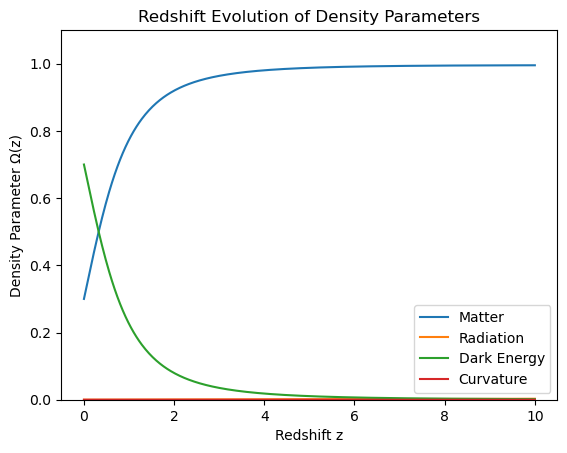

In [4]:
# Example: evolution of density parameters with redshift
import numpy as np
import matplotlib.pyplot as plt

# Present-day density parameters
Omega_m0 = 0.3
Omega_r0 = 8e-5
Omega_lambda0 = 0.7
Omega_K0 = 1 - (Omega_m0 + Omega_r0 + Omega_lambda0)

# Redshift array
z = np.linspace(0, 10, 500)

# E(z)^2
E2 = (Omega_m0 * (1+z)**3 +
      Omega_r0 * (1+z)**4 +
      Omega_lambda0 +
      Omega_K0 * (1+z)**2)

# Density parameters as function of z
Omega_m = Omega_m0 * (1+z)**3 / E2
Omega_r = Omega_r0 * (1+z)**4 / E2
Omega_lambda = Omega_lambda0 / E2
Omega_K = Omega_K0 * (1+z)**2 / E2

plt.plot(z, Omega_m, label='Matter')
plt.plot(z, Omega_r, label='Radiation')
plt.plot(z, Omega_lambda, label='Dark Energy')
plt.plot(z, Omega_K, label='Curvature')
plt.xlabel('Redshift z')
plt.ylabel('Density Parameter Ω(z)')
plt.title('Redshift Evolution of Density Parameters')
plt.legend()
plt.ylim(0,1.1)
plt.show()


### The Linear Growth Factor

The Friedmann equations describe how the background Universe expands, but they also determine how density perturbations grow over time. In the linear regime ($\delta \ll 1$), the growth of perturbations is governed by a single function called the **linear growth factor** $D_+(z)$.

The growth factor satisfies:

$$
\ddot{D}_+ + 2H\dot{D}_+ - \frac{3}{2} \Omega_m H^2 D_+ = 0
$$

Key features:
- During matter domination, $D_+ \propto a$ — perturbations grow proportionally to the scale factor.
- During radiation domination, growth is suppressed (the Meszaros effect).
- When dark energy begins to dominate, growth slows and eventually freezes out.

The `colossus` library provides the growth factor directly. Below we plot $D_+(a)$ from early times to the future, using the Planck 2018 cosmology.

In [ ]:
from colossus.cosmology import cosmology

cosmo = cosmology.setCosmology('planck18')

# Scale factor array from deep radiation era to the future
a = 10**np.linspace(-7.0, 1.5, 200)
z_growth = 1.0 / a - 1.0

# Compute the linear growth factor (normalized to D+ = 1 at z = 0)
D_plus = cosmo.growthFactor(z_growth)

# For comparison: D+ ~ a during matter domination
D_matter_dom = a / a[np.argmin(np.abs(z_growth))]  # normalized to match at a=1

# Radiation-matter equality
a_eq = 1.0 / (1.0 + cosmo.z_eq)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(a, D_plus, lw=2, color='C1', label=r'$D_+(a)$ (full solution)')
ax.loglog(a, D_matter_dom, '--', lw=1.5, color='C0', label=r'$D_+ \propto a$ (matter domination)')
ax.axvline(a_eq, ls='--', color='gray', lw=0.8, label=r'$a_{\rm eq}$')
ax.axvline(1.0, ls=':', color='gray', lw=0.7)
ax.axhline(1.0, ls=':', color='gray', lw=0.7)
ax.set_xlabel(r'Scale factor $a$')
ax.set_ylabel(r'Growth factor $D_+(a)$')
ax.set_xlim(a[0], a[-1])
ax.set_ylim(2e-4, 50.0)
ax.set_title('Linear Growth Factor: from Friedmann Equations to Structure Formation')
ax.legend(frameon=True, labelspacing=0.3)
plt.tight_layout()
plt.show()

print(f"Growth factor today (z=0):    D+ = {cosmo.growthFactor(0.0):.3f}")
print(f"Growth factor at z=1:         D+ = {cosmo.growthFactor(1.0):.3f}")
print(f"Radiation-matter equality:    z_eq = {cosmo.z_eq:.0f},  a_eq = {a_eq:.2e}")

# Summary

Physical laws can be expressed in a manifestly invariant form using tensors, which ensures that the laws hold in any coordinate system.

The geometry of space-time is described by the metric tensor $g_{\mu\nu}$.  

The Friedmann–Robertson–Walker (FRW) metric is the most general metric consistent with the cosmological principle:

- The Universe is homogeneous (the same at all locations)  
- The Universe is isotropic (the same in all directions)  

Mathematically, the FRW metric is written as:

$$
g_{\mu\nu} = g_{\mu\nu}(x)
$$

Key points about the cosmological components:

- The peculiar velocities of particles that do not experience external forces decay with the expansion of the Universe:

$$
v_\text{pec} \propto a^{-1}
$$

- Baryons and dark matter are non-relativistic and evolve in the same way, so they can be treated as a single matter component.  
- Radiation and relativistic matter (e.g., neutrinos) evolve similarly and can be treated as a single relativistic component.
